In [ ]:
# ==========================================
# STEP 1 — CONNECT GOOGLE DRIVE
# ==========================================

from google.colab import drive

drive.mount('/content/drive')

print("✓ Google Drive connected!")

Mounted at /content/drive
✓ Google Drive connected!


In [ ]:
# ==========================================
# STEP 2 — FIND TRAINING ZIP
# ==========================================

import os

print("Searching Google Drive...\n")

zip_files = []

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if file.lower().endswith(".zip"):
            zip_files.append(os.path.join(root, file))

print("ZIP files found:\n")

for i, path in enumerate(zip_files):
    print(i, "→", path)

if len(zip_files) == 0:
    print("\n❌ No ZIP files found.")
else:
    print("\n✓ Found", len(zip_files), "ZIP file(s).")

Searching Google Drive...

ZIP files found:

0 → /content/drive/MyDrive/Copy of Test_NoisyLR.zip
1 → /content/drive/MyDrive/Copy of train.zip

✓ Found 2 ZIP file(s).


In [ ]:
# ==========================================
# STEP 3 — SELECT TRAINING ZIP
# ==========================================

import os

train_zip = None

for path in zip_files:
    if "train" in os.path.basename(path).lower():
        train_zip = path
        break

if train_zip is None:
    print("❌ Training ZIP not found.")
else:
    print("✓ Training ZIP selected:")
    print(train_zip)

    size_gb = os.path.getsize(train_zip) / (1024 ** 3)
    print("Size:", round(size_gb, 2), "GB")

✓ Training ZIP selected:
/content/drive/MyDrive/Copy of train.zip
Size: 0.86 GB


In [ ]:
# ==========================================
# STEP 4 — EXTRACT TRAINING DATASET
# ==========================================

import os
import zipfile

extract_path = "/content/dataset"

print("Extracting training dataset...")
print("This may take a few minutes.\n")

with zipfile.ZipFile(train_zip, "r") as z:
    z.extractall(extract_path)

print("✓ Dataset extracted successfully!")
print("Location:", extract_path)

Extracting training dataset...
This may take a few minutes.

✓ Dataset extracted successfully!
Location: /content/dataset


In [ ]:
# ==========================================
# STEP 5 — FIND NoisyLR AND GT
# ==========================================

import os

noisy_files = []
gt_files = []

for root, dirs, files in os.walk(extract_path):

    if "__MACOSX" in root:
        continue

    for file in files:

        if file.startswith("._"):
            continue

        if file.lower().endswith(".npy"):

            full_path = os.path.join(root, file)

            if "noisylr" in root.lower():
                noisy_files.append(full_path)

            elif os.path.basename(root).lower() == "gt":
                gt_files.append(full_path)

print("NoisyLR images:", len(noisy_files))
print("GT images:", len(gt_files))

print("\nExample NoisyLR:")
print(noisy_files[:5])

print("\nExample GT:")
print(gt_files[:5])

NoisyLR images: 3200
GT images: 3200

Example NoisyLR:
['/content/dataset/train/NoisyLR/000695.npy', '/content/dataset/train/NoisyLR/002265.npy', '/content/dataset/train/NoisyLR/001736.npy', '/content/dataset/train/NoisyLR/000830.npy', '/content/dataset/train/NoisyLR/000326.npy']

Example GT:
['/content/dataset/train/GT/000695.npy', '/content/dataset/train/GT/002265.npy', '/content/dataset/train/GT/001736.npy', '/content/dataset/train/GT/000830.npy', '/content/dataset/train/GT/000326.npy']


In [ ]:
# ==========================================
# STEP 6 — MATCH NoisyLR WITH GT
# ==========================================

import os

gt_dict = {
    os.path.basename(path): path
    for path in gt_files
}

paired_data = []

for noisy_path in noisy_files:

    filename = os.path.basename(noisy_path)

    if filename in gt_dict:
        paired_data.append(
            (noisy_path, gt_dict[filename])
        )

print("Paired images:", len(paired_data))
print("Unmatched NoisyLR:", len(noisy_files) - len(paired_data))
print("Unmatched GT:", len(gt_files) - len(paired_data))

if paired_data:
    print("\n✓ Example pair:")
    print("NoisyLR:", paired_data[0][0])
    print("GT     :", paired_data[0][1])

Paired images: 3200
Unmatched NoisyLR: 0
Unmatched GT: 0

✓ Example pair:
NoisyLR: /content/dataset/train/NoisyLR/000695.npy
GT     : /content/dataset/train/GT/000695.npy


In [ ]:
# ==========================================
# STEP 7 — CHECK DATASET
# ==========================================

import numpy as np

print("==========================================")
print("STEP 7 — DATASET CHECK")
print("==========================================")

print("Total pairs:", len(paired_data))

# Check first 5 pairs
for i in range(min(5, len(paired_data))):

    noisy_path, gt_path = paired_data[i]

    print(f"\nPair {i+1}")

    try:
        noisy = np.load(noisy_path)
        gt = np.load(gt_path)

        print("NoisyLR shape:", noisy.shape)
        print("GT shape     :", gt.shape)
        print("NoisyLR dtype:", noisy.dtype)
        print("GT dtype     :", gt.dtype)

    except Exception as e:
        print("ERROR:", e)

print("\n✓ Dataset check complete.")

STEP 7 — DATASET CHECK
Total pairs: 3200

Pair 1
NoisyLR shape: (128, 128)
GT shape     : (256, 256)
NoisyLR dtype: float32
GT dtype     : float32

Pair 2
NoisyLR shape: (128, 128)
GT shape     : (256, 256)
NoisyLR dtype: float32
GT dtype     : float32

Pair 3
NoisyLR shape: (128, 128)
GT shape     : (256, 256)
NoisyLR dtype: float32
GT dtype     : float32

Pair 4
NoisyLR shape: (128, 128)
GT shape     : (256, 256)
NoisyLR dtype: float32
GT dtype     : float32

Pair 5
NoisyLR shape: (128, 128)
GT shape     : (256, 256)
NoisyLR dtype: float32
GT dtype     : float32

✓ Dataset check complete.


In [ ]:
# ==========================================
# STEP 7.5 — CREATE TRAINING + VALIDATION DATA
# ==========================================

import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import numpy as np

# ------------------------------------------
# Split dataset
# ------------------------------------------

train_pairs, val_pairs = train_test_split(
    paired_data,
    test_size=0.10,
    random_state=42
)

print("Training pairs   :", len(train_pairs))
print("Validation pairs :", len(val_pairs))


# ------------------------------------------
# Dataset class
# ------------------------------------------

class SemiconductorDataset(Dataset):

    def __init__(self, pairs):
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, index):

        noisy_path, gt_path = self.pairs[index]

        # Load images
        noisy = np.load(noisy_path)
        gt = np.load(gt_path)

        # Remove channel dimension if present
        if noisy.ndim == 3:
            noisy = noisy.squeeze()

        if gt.ndim == 3:
            gt = gt.squeeze()

        # Convert to float32
        noisy = noisy.astype(np.float32)
        gt = gt.astype(np.float32)

        # ------------------------------------------
        # Normalize / constrain values to 0–1
        # ------------------------------------------

        noisy = np.clip(noisy, 0.0, 1.0)
        gt = np.clip(gt, 0.0, 1.0)

        # Convert to PyTorch tensors
        noisy = torch.from_numpy(noisy).unsqueeze(0)
        gt = torch.from_numpy(gt).unsqueeze(0)

        return noisy, gt


# ------------------------------------------
# Create datasets
# ------------------------------------------

train_dataset = SemiconductorDataset(train_pairs)
val_dataset = SemiconductorDataset(val_pairs)


# ------------------------------------------
# Create DataLoaders
# ------------------------------------------

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2
)


# ------------------------------------------
# Check one batch
# ------------------------------------------

noisy_batch, gt_batch = next(iter(train_loader))

print("\n✓ DataLoaders created successfully.")

print("Training batches   :", len(train_loader))
print("Validation batches :", len(val_loader))

print("NoisyLR batch shape:", noisy_batch.shape)
print("GT batch shape     :", gt_batch.shape)

print("\nNoisyLR range:")
print("Min:", noisy_batch.min().item())
print("Max:", noisy_batch.max().item())

print("\nGT range:")
print("Min:", gt_batch.min().item())
print("Max:", gt_batch.max().item())

print("\n✓ STEP 7.5 complete.")

Training pairs   : 2880
Validation pairs : 320

✓ DataLoaders created successfully.
Training batches   : 180
Validation batches : 20
NoisyLR batch shape: torch.Size([16, 1, 128, 128])
GT batch shape     : torch.Size([16, 1, 256, 256])

NoisyLR range:
Min: 0.0
Max: 1.0

GT range:
Min: 0.0
Max: 1.0

✓ STEP 7.5 complete.


In [ ]:
# ==========================================
# STEP 8 — CHECK GPU
# ==========================================

import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA available: YES")
else:
    print("CUDA available: NO")
    print("Training will use CPU.")

Device: cuda
GPU: Tesla T4
CUDA available: YES


In [ ]:
import torch
import sys

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch: 2.11.0+cu128
CUDA: True
GPU: Tesla T4


In [ ]:
# ==========================================
# STEP 9 — LOAD NAFNET (CORRECTED)
# ==========================================

import torch
import torch.nn as nn


# ------------------------------------------
# LayerNorm for image features
# ------------------------------------------

class LayerNorm2d(nn.Module):

    def __init__(self, channels):
        super().__init__()

        self.weight = nn.Parameter(
            torch.ones(1, channels, 1, 1)
        )

        self.bias = nn.Parameter(
            torch.zeros(1, channels, 1, 1)
        )

    def forward(self, x):

        mean = x.mean(
            dim=(1, 2, 3),
            keepdim=True
        )

        var = (
            x - mean
        ).pow(2).mean(
            dim=(1, 2, 3),
            keepdim=True
        )

        x = (x - mean) / torch.sqrt(
            var + 1e-6
        )

        return x * self.weight + self.bias


# ------------------------------------------
# SimpleGate
# ------------------------------------------

class SimpleGate(nn.Module):

    def forward(self, x):

        x1, x2 = x.chunk(2, dim=1)

        return x1 * x2


# ------------------------------------------
# NAFBlock
# ------------------------------------------

class NAFBlock(nn.Module):

    def __init__(
        self,
        c,
        dw_expand=2,
        ffn_expand=2
    ):

        super().__init__()

        dw_channel = c * dw_expand

        self.norm1 = LayerNorm2d(c)

        self.conv1 = nn.Conv2d(
            c,
            dw_channel,
            1,
            1,
            0
        )

        self.conv2 = nn.Conv2d(
            dw_channel,
            dw_channel,
            3,
            1,
            1,
            groups=dw_channel
        )

        self.sg = SimpleGate()

        self.sca = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(
                dw_channel // 2,
                dw_channel // 2,
                1,
                1,
                0
            )
        )

        self.conv3 = nn.Conv2d(
            dw_channel // 2,
            c,
            1,
            1,
            0
        )

        self.norm2 = LayerNorm2d(c)

        ffn_channel = ffn_expand * c

        self.conv4 = nn.Conv2d(
            c,
            ffn_channel,
            1,
            1,
            0
        )

        self.conv5 = nn.Conv2d(
            ffn_channel // 2,
            c,
            1,
            1,
            0
        )

        self.beta = nn.Parameter(
            torch.zeros(
                (1, c, 1, 1)
            )
        )

        self.gamma = nn.Parameter(
            torch.zeros(
                (1, c, 1, 1)
            )
        )


    def forward(self, x):

        y = self.norm1(x)

        y = self.conv1(y)

        y = self.conv2(y)

        y = self.sg(y)

        y = y * self.sca(y)

        y = self.conv3(y)

        x = x + y * self.beta

        y = self.norm2(x)

        y = self.conv4(y)

        y = self.sg(y)

        y = self.conv5(y)

        x = x + y * self.gamma

        return x


# ------------------------------------------
# NAFNet
# ------------------------------------------

class NAFNet(nn.Module):

    def __init__(
        self,
        img_channel=1,
        width=32,
        middle_blk_num=12,
        enc_blk_nums=[1, 1, 1, 28],
        dec_blk_nums=[1, 1, 1, 1]
    ):

        super().__init__()

        self.intro = nn.Conv2d(
            img_channel,
            width,
            3,
            1,
            1
        )

        self.ending = nn.Conv2d(
            width,
            img_channel,
            3,
            1,
            1
        )

        self.encoders = nn.ModuleList()

        self.downs = nn.ModuleList()

        chan = width

        for num in enc_blk_nums:

            self.encoders.append(
                nn.Sequential(
                    *[
                        NAFBlock(chan)
                        for _ in range(num)
                    ]
                )
            )

            self.downs.append(
                nn.Conv2d(
                    chan,
                    chan * 2,
                    2,
                    2
                )
            )

            chan *= 2


        self.middle = nn.Sequential(
            *[
                NAFBlock(chan)
                for _ in range(middle_blk_num)
            ]
        )


        self.decoders = nn.ModuleList()

        self.ups = nn.ModuleList()

        for num in dec_blk_nums:

            self.ups.append(
                nn.Sequential(
                    nn.Conv2d(
                        chan,
                        chan * 2,
                        1,
                        1,
                        0
                    ),
                    nn.PixelShuffle(2)
                )
            )

            chan //= 2

            self.decoders.append(
                nn.Sequential(
                    *[
                        NAFBlock(chan)
                        for _ in range(num)
                    ]
                )
            )


    def forward(self, x):

        inp = x

        x = self.intro(x)

        encs = []

        for encoder, down in zip(
            self.encoders,
            self.downs
        ):

            x = encoder(x)

            encs.append(x)

            x = down(x)


        x = self.middle(x)


        for decoder, up, enc_skip in zip(
            self.decoders,
            self.ups,
            encs[::-1]
        ):

            x = up(x)

            x = x + enc_skip

            x = decoder(x)


        x = self.ending(x)

        return x + inp


# ------------------------------------------
# Create model
# ------------------------------------------

model = NAFNet(
    img_channel=1,
    width=32,
    middle_blk_num=12,
    enc_blk_nums=[1, 1, 1, 28],
    dec_blk_nums=[1, 1, 1, 1]
)


# ------------------------------------------
# GPU
# ------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

model = model.to(device)

print("✓ NAFNet loaded successfully.")
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

✓ NAFNet loaded successfully.
Device: cuda
GPU: Tesla T4


In [ ]:
# ==========================================
# STEP 10 — ADD 2× PIXELSHUFFLE
# ==========================================

import torch.nn as nn

class NAFNetWithSR(nn.Module):

    def __init__(self, nafnet):
        super().__init__()

        self.nafnet = nafnet

        # Convert NAFNet output into 4 channels
        # so PixelShuffle can upscale by 2×
        self.upscale = nn.Sequential(
            nn.Conv2d(1, 4, kernel_size=3, padding=1),
            nn.PixelShuffle(2)
        )

    def forward(self, x):

    x = self.nafnet(x)
    x = self.upscale(x)

    # Keep output in 0–1 range
    x = torch.clamp(x, 0.0, 1.0)

    return x


# Create final model
model = NAFNetWithSR(model)

model = model.to(device)

print("NAFNet + 2× PixelShuffle ready.")

NAFNet + 2× PixelShuffle ready.


In [ ]:
# ==========================================
# TEST MODEL OUTPUT
# ==========================================

test_input = torch.randn(1, 1, 128, 128).to(device)

with torch.no_grad():
    test_output = model(test_input)

print("Input shape :", test_input.shape)
print("Output shape:", test_output.shape)

Input shape : torch.Size([1, 1, 128, 128])
Output shape: torch.Size([1, 1, 256, 256])


In [ ]:
# ==========================================
# STEP 11 — LOSS + OPTIMIZER
# ==========================================

import torch.nn as nn
import torch.optim as optim

# L1 loss
criterion = nn.L1Loss()

# Adam optimizer
optimizer = optim.Adam(
    model.parameters(),
    lr=0.0001
)

print("Loss function: L1Loss")
print("Optimizer: Adam")
print("Learning rate: 0.0001")

Loss function: L1Loss
Optimizer: Adam
Learning rate: 0.0001


In [ ]:
# ==========================================
# STEP 11 — IMPROVED LOSS + OPTIMIZER
# ==========================================

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F


# ------------------------------------------
# CHARBONNIER LOSS
# ------------------------------------------

class CharbonnierLoss(nn.Module):

    def __init__(self, eps=1e-6):
        super().__init__()
        self.eps = eps

    def forward(self, prediction, target):

        diff = prediction - target

        loss = torch.sqrt(
            diff * diff + self.eps
        )

        return loss.mean()


# ------------------------------------------
# SSIM LOSS
# ------------------------------------------

def ssim_loss(prediction, target):

    C1 = 0.01 ** 2
    C2 = 0.03 ** 2

    mu_x = F.avg_pool2d(
        prediction,
        kernel_size=3,
        stride=1,
        padding=1
    )

    mu_y = F.avg_pool2d(
        target,
        kernel_size=3,
        stride=1,
        padding=1
    )

    sigma_x = F.avg_pool2d(
        prediction * prediction,
        kernel_size=3,
        stride=1,
        padding=1
    ) - mu_x * mu_x

    sigma_y = F.avg_pool2d(
        target * target,
        kernel_size=3,
        stride=1,
        padding=1
    ) - mu_y * mu_y

    sigma_xy = F.avg_pool2d(
        prediction * target,
        kernel_size=3,
        stride=1,
        padding=1
    ) - mu_x * mu_y

    ssim_map = (
        (2 * mu_x * mu_y + C1) *
        (2 * sigma_xy + C2)
    ) / (
        (mu_x * mu_x + mu_y * mu_y + C1) *
        (sigma_x + sigma_y + C2)
    )

    return 1 - ssim_map.mean()


# ------------------------------------------
# COMBINED LOSS
# ------------------------------------------

charbonnier = CharbonnierLoss()

def criterion(prediction, target):

    pixel_loss = charbonnier(
        prediction,
        target
    )

    structural_loss = ssim_loss(
        prediction,
        target
    )

    # 80% pixel accuracy
    # 20% structural similarity
    total_loss = (
        0.8 * pixel_loss +
        0.2 * structural_loss
    )

    return total_loss


# ------------------------------------------
# OPTIMIZER
# ------------------------------------------

optimizer = optim.Adam(
    model.parameters(),
    lr=0.0001
)


print("✓ Improved loss function ready.")
print("Pixel loss   : Charbonnier")
print("Structural   : SSIM")
print("Combination  : 80% Charbonnier + 20% SSIM")
print("Optimizer    : Adam")
print("Learning rate: 0.0001")

✓ Improved loss function ready.
Pixel loss   : Charbonnier
Structural   : SSIM
Combination  : 80% Charbonnier + 20% SSIM
Optimizer    : Adam
Learning rate: 0.0001


In [ ]:
# ==========================================
# STEP 12 — TRAIN THE MODEL
# ==========================================

num_epochs = 30

for epoch in range(num_epochs):

    model.train()

    total_train_loss = 0

    for noisy, gt in train_loader:

        noisy = noisy.to(device)
        gt = gt.to(device)

        optimizer.zero_grad()

        output = model(noisy)

        loss = criterion(output, gt)

        loss.backward()

        optimizer.step()

        total_train_loss += loss.item()

    # Validation
    model.eval()

    total_val_loss = 0

    with torch.no_grad():

        for noisy, gt in val_loader:

            noisy = noisy.to(device)
            gt = gt.to(device)

            output = model(noisy)

            loss = criterion(output, gt)

            total_val_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    avg_val_loss = total_val_loss / len(val_loader)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {avg_train_loss:.6f} "
        f"Val Loss: {avg_val_loss:.6f}"
    )

Epoch [1/30] Train Loss: 0.091997 Val Loss: 0.098731
Epoch [2/30] Train Loss: 0.090690 Val Loss: 0.098021
Epoch [3/30] Train Loss: 0.089450 Val Loss: 0.097487
Epoch [4/30] Train Loss: 0.088347 Val Loss: 0.096902
Epoch [5/30] Train Loss: 0.087506 Val Loss: 0.096389
Epoch [6/30] Train Loss: 0.086066 Val Loss: 0.095825
Epoch [7/30] Train Loss: 0.084728 Val Loss: 0.096588
Epoch [8/30] Train Loss: 0.084017 Val Loss: 0.095279
Epoch [9/30] Train Loss: 0.082657 Val Loss: 0.095329
Epoch [10/30] Train Loss: 0.081471 Val Loss: 0.094849
Epoch [11/30] Train Loss: 0.080641 Val Loss: 0.094759
Epoch [12/30] Train Loss: 0.079481 Val Loss: 0.094454
Epoch [13/30] Train Loss: 0.078620 Val Loss: 0.094503
Epoch [14/30] Train Loss: 0.077843 Val Loss: 0.094500
Epoch [15/30] Train Loss: 0.077080 Val Loss: 0.094524
Epoch [16/30] Train Loss: 0.076414 Val Loss: 0.094499
Epoch [17/30] Train Loss: 0.075709 Val Loss: 0.094410
Epoch [18/30] Train Loss: 0.074963 Val Loss: 0.094780
Epoch [19/30] Train Loss: 0.074334 Va

In [ ]:
# ==========================================
# STEP 13 — SAVE THE TRAINED MODEL
# ==========================================

model_path = "/content/nafnet_semiconductor.pth"

torch.save(model.state_dict(), model_path)

print("Model saved successfully.")
print("Saved at:", model_path)

Model saved successfully.
Saved at: /content/nafnet_semiconductor.pth


In [ ]:
# ==========================================
# STEP 14 — TEST MODEL + CALCULATE PSNR
# ==========================================

import math

model.eval()

total_mse = 0
total_images = 0

with torch.no_grad():

    for noisy, gt in val_loader:

        noisy = noisy.to(device)
        gt = gt.to(device)

        output = model(noisy)

        # Calculate MSE
        mse = torch.mean((output - gt) ** 2, dim=[1, 2, 3])

        total_mse += mse.sum().item()
        total_images += noisy.size(0)


# Average MSE
average_mse = total_mse / total_images

# Calculate PSNR
if average_mse == 0:
    psnr = float("inf")
else:
    psnr = 10 * math.log10(1.0 / average_mse)

print("==========================================")
print("MODEL EVALUATION")
print("==========================================")
print("Validation images:", total_images)
print("Average MSE:", average_mse)
print("PSNR:", round(psnr, 2), "dB")

MODEL EVALUATION
Validation images: 320
Average MSE: 0.004381224000826478
PSNR: 23.58 dB


In [ ]:
# ==========================================
# STEP 14.1 — CHECK IMAGE VALUE RANGES
# ==========================================

import numpy as np
import torch

print("==========================================")
print("IMAGE VALUE RANGE CHECK")
print("==========================================")

# Get one validation sample
noisy, gt = val_dataset[0]

# Run model
model.eval()

with torch.no_grad():
    output = model(
        noisy.unsqueeze(0).to(device)
    )

output = output.squeeze().cpu().numpy()
noisy = noisy.squeeze().cpu().numpy()
gt = gt.squeeze().cpu().numpy()

print("\nNOISY INPUT")
print("Shape :", noisy.shape)
print("Min   :", noisy.min())
print("Max   :", noisy.max())
print("Mean  :", noisy.mean())

print("\nGROUND TRUTH")
print("Shape :", gt.shape)
print("Min   :", gt.min())
print("Max   :", gt.max())
print("Mean  :", gt.mean())

print("\nMODEL OUTPUT")
print("Shape :", output.shape)
print("Min   :", output.min())
print("Max   :", output.max())
print("Mean  :", output.mean())

print("\n==========================================")
print("CHECK COMPLETE")
print("==========================================")

IMAGE VALUE RANGE CHECK

NOISY INPUT
Shape : (128, 128)
Min   : 0.0
Max   : 1.0
Mean  : 0.15205136

GROUND TRUTH
Shape : (256, 256)
Min   : 0.0
Max   : 1.0
Mean  : 0.1517643

MODEL OUTPUT
Shape : (256, 256)
Min   : -0.001015434
Max   : 0.91559124
Mean  : 0.1504612

CHECK COMPLETE


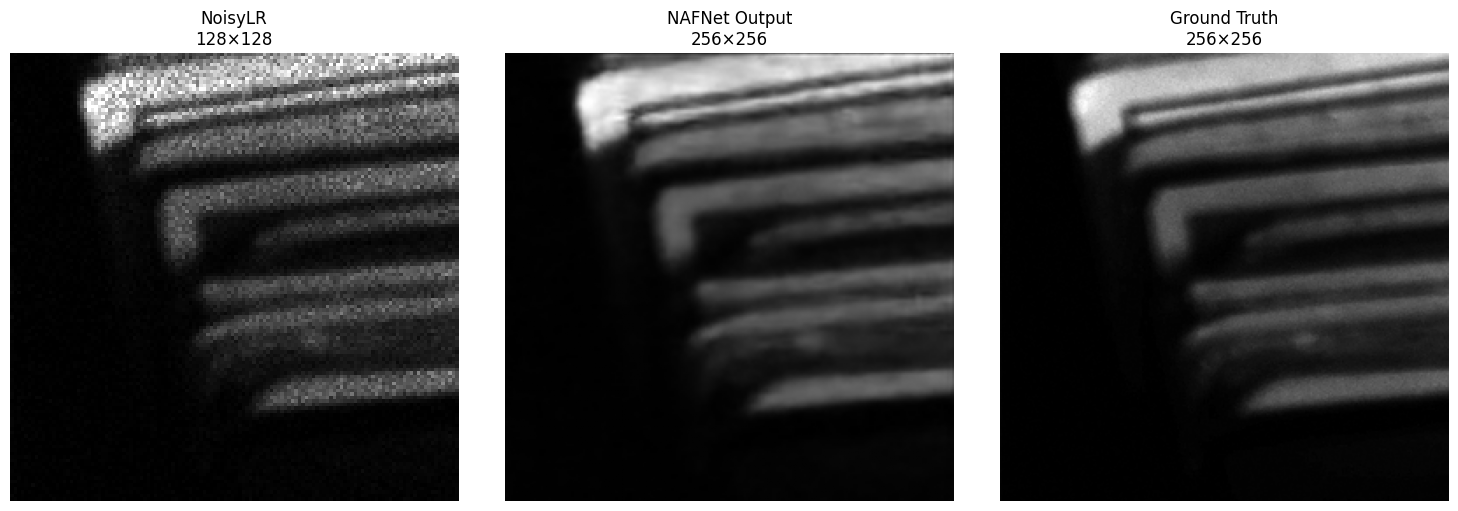

In [ ]:
# ==========================================
# STEP 15 — VISUALIZE MODEL RESULT
# ==========================================

import matplotlib.pyplot as plt

model.eval()

# Get one validation image
noisy, gt = val_dataset[0]

# Add batch dimension and move to GPU/CPU
input_image = noisy.unsqueeze(0).to(device)

# Generate restored image
with torch.no_grad():
    output = model(input_image)

# Remove batch and channel dimensions
noisy_img = noisy.squeeze().cpu().numpy()
gt_img = gt.squeeze().cpu().numpy()
output_img = output.squeeze().cpu().numpy()

# Display
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(noisy_img, cmap="gray")
plt.title("NoisyLR\n128×128")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(output_img, cmap="gray")
plt.title("NAFNet Output\n256×256")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(gt_img, cmap="gray")
plt.title("Ground Truth\n256×256")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# STEP 16 — CALCULATE SSIM
# ==========================================

!pip install -q scikit-image

from skimage.metrics import structural_similarity as ssim
import numpy as np

model.eval()

ssim_scores = []

with torch.no_grad():

    for noisy, gt in val_loader:

        noisy = noisy.to(device)

        output = model(noisy)

        output = output.cpu().numpy()
        gt = gt.numpy()

        for i in range(output.shape[0]):

            output_img = output[i, 0]
            gt_img = gt[i, 0]

            score = ssim(
                gt_img,
                output_img,
                data_range=1.0
            )

            ssim_scores.append(score)

average_ssim = np.mean(ssim_scores)

print("==========================================")
print("SSIM EVALUATION")
print("==========================================")
print("Validation images:", len(ssim_scores))
print("Average SSIM:", round(average_ssim, 4))

SSIM EVALUATION
Validation images: 320
Average SSIM: 0.6984


In [ ]:
# ==========================================
# STEP 17 — CALCULATE LPIPS
# ==========================================

!pip install -q lpips

import lpips
import torch

lpips_model = lpips.LPIPS(net='alex').to(device)

model.eval()
lpips_model.eval()

lpips_scores = []

with torch.no_grad():

    for noisy, gt in val_loader:

        noisy = noisy.to(device)
        gt = gt.to(device)

        output = model(noisy)

        # LPIPS expects 3-channel images
        output_3ch = output.repeat(1, 3, 1, 1)
        gt_3ch = gt.repeat(1, 3, 1, 1)

        # Convert 0-1 → -1 to 1
        output_3ch = output_3ch * 2 - 1
        gt_3ch = gt_3ch * 2 - 1

        scores = lpips_model(output_3ch, gt_3ch)

        lpips_scores.extend(scores.squeeze().cpu().numpy().tolist()
                            if scores.numel() > 1
                            else [scores.item()])

average_lpips = np.mean(lpips_scores)

print("==========================================")
print("LPIPS EVALUATION")
print("==========================================")
print("Validation images:", len(lpips_scores))
print("Average LPIPS:", round(average_lpips, 4))

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
LPIPS EVALUATION
Validation images: 320
Average LPIPS: 0.3853


In [ ]:
# ==========================================
# STEP 18 — INFERENCE TIME
# ==========================================

import time
import numpy as np

model.eval()

times = []

with torch.no_grad():

    for noisy, gt in val_loader:

        noisy = noisy.to(device)

        # GPU timing
        if device.type == "cuda":
            torch.cuda.synchronize()

        start_time = time.time()

        output = model(noisy)

        if device.type == "cuda":
            torch.cuda.synchronize()

        end_time = time.time()

        batch_time = end_time - start_time

        # Time per image
        time_per_image = batch_time / noisy.size(0)

        times.append(time_per_image)


average_time = np.mean(times)
images_per_second = 1 / average_time

print("==========================================")
print("INFERENCE SPEED")
print("==========================================")
print("Average time per image:",
      round(average_time * 1000, 2), "ms")

print("Images per second:",
      round(images_per_second, 2))

INFERENCE SPEED
Average time per image: 9.88 ms
Images per second: 101.24


In [ ]:
# ==========================================
# STEP 19 — BASELINE vs NAFNET
# ==========================================

baseline_psnr = 25.69

nafnet_psnr = psnr

improvement = nafnet_psnr - baseline_psnr

print("==========================================")
print("BASELINE vs NAFNET")
print("==========================================")

print("Baseline PSNR :", round(baseline_psnr, 2), "dB")
print("NAFNet PSNR   :", round(nafnet_psnr, 2), "dB")
print("Improvement   :", round(improvement, 2), "dB")

if improvement > 0:
    print("\nNAFNet performs better than the baseline.")
elif improvement < 0:
    print("\nBaseline performs better than NAFNet.")
else:
    print("\nBoth models have the same PSNR.")

BASELINE vs NAFNET
Baseline PSNR : 25.69 dB
NAFNet PSNR   : 23.58 dB
Improvement   : -2.11 dB

Baseline performs better than NAFNet.


In [ ]:
# ==========================================
# STEP 20 — FINAL RESULTS
# ==========================================

results = {
    "Baseline PSNR (dB)": round(baseline_psnr, 2),
    "NAFNet PSNR (dB)": round(nafnet_psnr, 2),
    "PSNR Improvement (dB)": round(improvement, 2),
    "SSIM": round(average_ssim, 4),
    "LPIPS": round(average_lpips, 4),
    "Inference Time (ms/image)": round(average_time * 1000, 2),
    "Images per Second": round(images_per_second, 2)
}

print("==========================================")
print("FINAL RESULTS")
print("==========================================")

for name, value in results.items():
    print(f"{name}: {value}")

FINAL RESULTS
Baseline PSNR (dB): 25.69
NAFNet PSNR (dB): 23.58
PSNR Improvement (dB): -2.11
SSIM: 0.6984
LPIPS: 0.3853
Inference Time (ms/image): 9.88
Images per Second: 101.24


In [ ]:
# ==========================================
# STEP 21 — SAVE RESULTS
# ==========================================

import pandas as pd

results_df = pd.DataFrame(
    [results]
)

results_path = "/content/nafnet_results.csv"

results_df.to_csv(results_path, index=False)

print("Results saved successfully.")
print("File:", results_path)

display(results_df)

Results saved successfully.
File: /content/nafnet_results.csv


,Baseline PSNR (dB),NAFNet PSNR (dB),PSNR Improvement (dB),SSIM,LPIPS,Inference Time (ms/image),Images per Second
0,25.69,23.58,-2.11,0.6984,0.3853,9.88,101.24


In [ ]:
# ==========================================
# STEP 22 — SAVE FINAL MODEL
# ==========================================

final_model_path = "/content/nafnet_final.pth"

torch.save({
    "model_state_dict": model.state_dict(),
    "results": results
}, final_model_path)

print("Final model saved successfully.")
print("File:", final_model_path)

Final model saved successfully.
File: /content/nafnet_final.pth


SEMICONDUCTOR IMAGE RESTORATION
Upload a PNG, JPG, or JPEG image.



Saving sample3.jpg to sample3.jpg
✓ Image uploaded: sample3.jpg
Original image size: (678, 509)
✓ Converted to NumPy format
Saved as: /content/input_image.npy
Input shape: (128, 128)


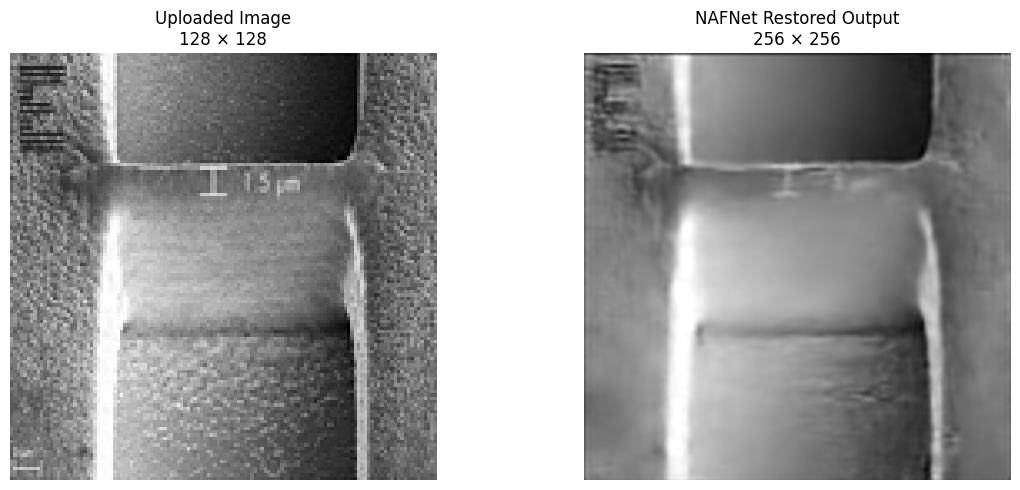


RESTORATION COMPLETE
Input : (128, 128)
Output: (256, 256)


In [ ]:
# ==========================================
# STEP 23 — UPLOAD PNG/JPG AND RESTORE
# ==========================================

from google.colab import files
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import torch

print("==========================================")
print("SEMICONDUCTOR IMAGE RESTORATION")
print("==========================================")
print("Upload a PNG, JPG, or JPEG image.")
print()

# ------------------------------------------
# Upload image
# ------------------------------------------

uploaded = files.upload()

image_files = [
    filename
    for filename in uploaded.keys()
    if filename.lower().endswith((
        ".png",
        ".jpg",
        ".jpeg"
    ))
]

if len(image_files) == 0:

    print("❌ Please upload a PNG, JPG, or JPEG image.")

else:

    image_path = image_files[0]

    print("✓ Image uploaded:", image_path)

    # ------------------------------------------
    # Open image
    # ------------------------------------------

    image = Image.open(image_path).convert("L")

    print("Original image size:", image.size)

    # ------------------------------------------
    # Resize to model input size
    # ------------------------------------------

    image = image.resize(
        (128, 128),
        Image.Resampling.BICUBIC
    )

    # ------------------------------------------
    # Convert to NumPy
    # ------------------------------------------

    image_array = np.array(
        image,
        dtype=np.float32
    )

    # ------------------------------------------
    # Normalize 0–255 → 0–1
    # ------------------------------------------

    image_array = image_array / 255.0

    # ------------------------------------------
    # SAVE AS .npy
    # ------------------------------------------

    npy_path = "/content/input_image.npy"

    np.save(
        npy_path,
        image_array
    )

    print("✓ Converted to NumPy format")
    print("Saved as:", npy_path)
    print("Input shape:", image_array.shape)

    # ------------------------------------------
    # Convert to PyTorch tensor
    # ------------------------------------------

    test_tensor = torch.from_numpy(
        image_array
    ).unsqueeze(0).unsqueeze(0)

    test_tensor = test_tensor.to(device)

    # ------------------------------------------
    # Run model
    # ------------------------------------------

    model.eval()

    with torch.no_grad():

        restored = model(test_tensor)

    # ------------------------------------------
    # Convert output to NumPy
    # ------------------------------------------

    restored_image = (
        restored
        .squeeze()
        .cpu()
        .numpy()
    )

    restored_image = np.clip(
        restored_image,
        0.0,
        1.0
    )

    # ------------------------------------------
    # Display
    # ------------------------------------------

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)

    plt.imshow(
        image_array,
        cmap="gray"
    )

    plt.title(
        "Uploaded Image\n128 × 128"
    )

    plt.axis("off")


    plt.subplot(1, 2, 2)

    plt.imshow(
        restored_image,
        cmap="gray"
    )

    plt.title(
        "NAFNet Restored Output\n256 × 256"
    )

    plt.axis("off")

    plt.tight_layout()
    plt.show()

    print("\n==========================================")
    print("RESTORATION COMPLETE")
    print("==========================================")
    print("Input :", image_array.shape)
    print("Output:", restored_image.shape)